
#### Introduction

>   Sentiment analysis systems, as one of the most important applications of natural language processing, play a vital role in automated understanding of emotions and opinions in texts. These systems are now used in various fields such as social surveys, customer feedback analysis, brand reputation management, and even market research.
>   
>   Large language models like GPT have created a remarkable transformation in the field of natural language processing. These models, with their transformer-based architecture and training on vast amounts of textual data, acquire the ability to understand the most complex language patterns. The GPT model family, from GPT-1 to GPT-4, with self-supervised learning and unidirectional attention, have the ability to generate coherent texts and answer questions.
>   
>   In this exercise, we use GPT-2 (a balanced version in terms of size and efficiency) to perform sentiment analysis on the IMDb dataset. Unlike traditional methods that use specialized classifiers like BERT, here we formulate the problem as conditional text generation; meaning that after reading a review, the model generates the word "positive" or "negative" as a response.
>   
>   The purpose of this exercise is to become familiar with fine-tuning pre-trained models, understand the differences between generative versus discriminative approaches, and examine the challenges of using GPT for classification tasks. Finally, we will evaluate the trained model with Accuracy and Perplexity metrics (which measure the model's confidence in predictions) and compare the results with baseline methods.
>   
#### 2-1. Paper Introduction (10 points)
>   
>   To become familiar with the theoretical foundations of transformer models, particularly the GPT architecture, read the paper from [this link](https://arxiv.org/abs/2005.14165) and answer the following in your report:
>   1. How does the unidirectional attention architecture in GPT work?
>   2. What are the key differences between GPT and BERT architectures?
>   3. How are pre-training and fine-tuning methods performed in GPT?
>   
#### 2-2. Data Preprocessing (30 points)
>   
>   In this section, we use the IMDb dataset which includes 50,000 movie reviews with positive and negative labels. This dataset is accessible through the datasets library:
>   ```python
>   # Load and prepare dataset
>   dataset = load_dataset("imdb")
>   ```
>   
>   a) Examine and display the class distribution, analyze text length with mean, median, maximum, and minimum metrics, and show a sample of raw data. For simplicity, you can use shorter reviews (minimum 500 characters).
>   
>   b) For formatting the data, use this format:
>   ```
>   "Review: {review text}\nSentiment: {label}"
>   ```
>   Convert numerical labels to text:
>   ```python
>   1 → "positive", 0 → "negative"
>   ```
>   
>   c) Use the GPT-2 tokenizer for tokenizing data:
>   ```python
>   tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
>   tokenizer.pad_token = tokenizer.eos_token
>   ```
>   
>   d) Create a data loader, find the appropriate batch size, and you can access these data by calling the train and test columns. To speed up the work, use 5000 samples from the train data and 1000 samples from the test data.
>   
#### 2-3. Model Implementation (50 points)
>   
>   In this part of the project, you are responsible for implementing a GPT-2 based model. This model should be implemented according to its specific architecture and the following important points:
>   ```python
>   model = GPT2LMHeadModel.from_pretrained("gpt2")
>   ```
>   
>   GPT-2 is one of the famous and powerful models in natural language processing. To start, you should use a pre-trained version of this model. This allows you to take advantage of the model's pre-learned knowledge and focus more on training the upper layers.
>   
>   One of the key points in this implementation is freezing the base layers of the model. With this, you will only train the upper (thinner) layers. This method usually helps increase training speed and prevent overfitting. By freezing the base layers, you can ensure that the model's basic features are preserved and only more specific aspects of the data are learned.
>   
>   To optimize the model's performance, adjusting hyperparameters such as learning rate, number of epochs, and batch sizes is very important. You should find the best combination of these parameters through initial experiments.
>   
>   In this implementation, the loss function should only be calculated for the labels. This means that you should focus only on the target data and ensure that the model is optimized for learning this data.

#### 2-4. Evaluation and Analysis of Results (10 points)

>   Now evaluate the model with accuracy metrics (which show how much of the model's predictions match the actual labels) and perplexity (which measures the model's confidence in predictions and the lower it is, the higher the confidence). Also, after calculating Recall and Precision, display its confusion matrix.
>   
>   Explain what the difference is between this method and using models like BERT, which is specifically built for classification? And examine the strengths and weaknesses of each method.

#### 2-5. Bonus (10 points)


>   Another approach for training pre-trained GPT models is using the LoRA (Low-Rank Adaptation) method with fewer resources while maintaining performance. LoRA adds trainable low-rank matrices to the model's original weights, allowing the model to be tuned without directly changing the pre-trained weights, reducing the number of parameters that need to be updated. Instead of freezing layers and limited use of the last two layers, try implementing the exercise with this technique.

### Answer

GPT uses **causal, or unidirectional, attention**—which basically means that when it's processing a sentence, each word can only "see" the words that came before it, not the ones that come after. To make that happen, the model adds a special triangular mask during self-attention. This mask blocks any future tokens by assigning them a very large negative value ($- \infty$), so when the model runs softmax, those future positions get zero probability. This ensures that the model processes text from left to right, just like we do when reading, which is exactly what we want for generating coherent language.

Because of this left-to-right design, **GPT is structurally similar to the decoder part of the original Transformer architecture**, while models like BERT use the encoder. GPT uses just one stack of transformer blocks with the causal mask, and it's trained to predict the next word in a sentence—making it especially good at generating long passages of text or answering prompts in a few-shot setting. BERT, on the other hand, drops the causal constraint and allows tokens to attend to both directions (past and future). It's trained to fill in missing words (masked language modeling) and to understand relationships between sentences. These tasks make BERT better suited for classification and other tasks where deep understanding of context is key.

The way we train these models reflects those design differences. GPT is **pretrained** on a huge datasets of raw text by simply trying to guess the next word. Then, when it's time to **fine-tune** it for a specific task, we usually keep that same *next-word* objective but tailor the input prompt to the task—for example: *"Review: ... Sentiment:"*. We can either update all of GPT’s layers, just the last few, or use lightweight plug-ins like **LoRA adapters**. No matter which one we do, the model stays generative—capable of completing text, answering questions, or making predictions in natural language.

In [1]:
# ------ Imports & Global Config ------
from pathlib import Path
import gc, logging, math, warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (GPT2LMHeadModel, GPT2Tokenizer,
                          get_linear_schedule_with_warmup,
                          logging as hf_logging)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ------ Hyper-Parameters ------
class CFG:
    MODEL_NAME              = "gpt2"
    DATASET_NAME            = "imdb"
    MIN_CHARS_PER_REVIEW    = 512
    MAX_SEQ_LEN             = 256
    TRAIN_SAMPLES           = 5000
    TEST_SAMPLES            = 1000
    BATCH_SIZE              = 8
    GRAD_ACCUM_STEPS        = 8
    EPOCHS                  = 2
    LR                      = 3e-5
    PROMPT_TEMPLATE         = "Review: {text}\nSentiment:"
    LABEL_TEXT              = {1: " positive", 0: " negative"}
    OUTPUT_DIR              = Path("./gpt2_sentiment_artifacts")
Config = CFG()

# ------ 3. Tokeniser Setup ------
tokeniser = GPT2Tokenizer.from_pretrained(Config.MODEL_NAME)
tokeniser.pad_token = tokeniser.eos_token      # GPT-2 has no PAD by default
LABEL_TOKENS = {k: tokeniser.encode(v, add_special_tokens=False)
                for k, v in Config.LABEL_TEXT.items()}

In [3]:
# ------ Helper: prompt -> tokens ------
def encode_examples(batch):
    """
    Converts raw IMDb examples into input_ids, attention_mask, labels.
    Only the label tokens contribute to the loss (others are set to -100).
    """
    inputs, masks, labels = [], [], []
    for review, y in zip(batch["text"], batch["label"]):
        prompt = Config.PROMPT_TEMPLATE.format(text=review)
        prompt_ids = tokeniser.encode(prompt, add_special_tokens=False)

        label_ids = LABEL_TOKENS[y]
        max_prompt = Config.MAX_SEQ_LEN - len(label_ids)        
        prompt_ids = prompt_ids[:max_prompt]                      

        seq = prompt_ids + label_ids
        pad_len = Config.MAX_SEQ_LEN - len(seq)
        seq += [tokeniser.pad_token_id] * pad_len
        mask = [1] * len(prompt_ids + label_ids) + [0] * pad_len

        lab = [-100] * Config.MAX_SEQ_LEN
        lab_start = len(prompt_ids)
        for k, tok in enumerate(label_ids):
            lab[lab_start + k] = tok

        inputs.append(seq); masks.append(mask); labels.append(lab)

    return {"input_ids": inputs, "attention_mask": masks, "labels": labels}


Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\Acer\.cache\huggingface\datasets\imdb\plain_text\0.0.0\e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Sun May 25 22:46:23 2025).


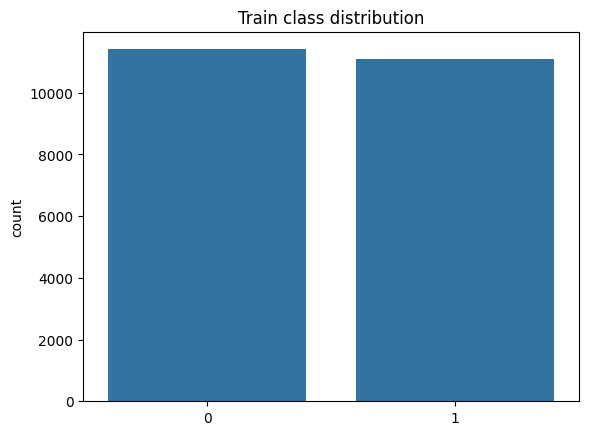

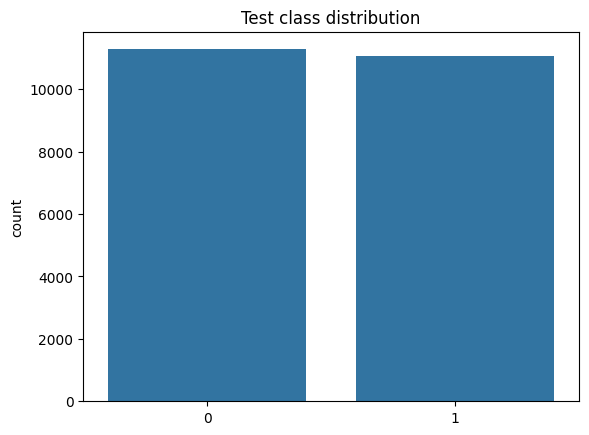

Min len: 512,  Max len: 13704,  Mean: 1432.8,  Median: 1058.0


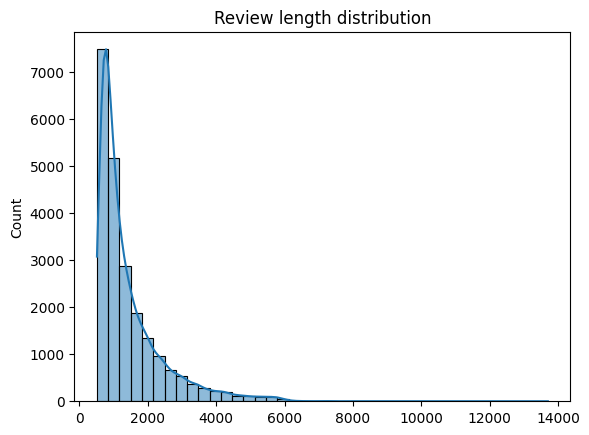

Sample review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h …


In [4]:
# ------ Load & Prepare Data ------
raw_ds = load_dataset(Config.DATASET_NAME)

# Filter for long reviews (500 chars) per assignment
long_train = raw_ds["train"].filter(lambda x: len(x["text"]) >= Config.MIN_CHARS_PER_REVIEW)
long_test = raw_ds["test"].filter(lambda x: len(x["text"])  >= Config.MIN_CHARS_PER_REVIEW)

# Exploratory stats
def show_dataset_stats():
    for split_name, split_ds in [("Train", long_train), ("Test", long_test)]:
        labels = split_ds["label"]
        sns.countplot(x=labels)
        plt.title(f"{split_name} class distribution"); plt.show()

    lengths = [len(t) for t in long_train["text"]]
    print(f"Min len: {min(lengths)},  Max len: {max(lengths)},  "
          f"Mean: {np.mean(lengths):.1f},  Median: {np.median(lengths):.1f}")
    sns.histplot(lengths, bins=40, kde=True); plt.title("Review length distribution"); plt.show()
    print("Sample review:", long_train["text"][0][:300], "…")
show_dataset_stats()

# Encode -> Arrow table
enc_train = long_train.shuffle(seed=42).select(range(Config.TRAIN_SAMPLES)).map(
    encode_examples, batched=True, remove_columns=long_train.column_names)
enc_test = long_test.shuffle(seed=42).select(range(Config.TEST_SAMPLES)).map(
    encode_examples, batched=True, remove_columns=long_test.column_names)

# Set tensor format
for split in (enc_train, enc_test):
    split.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_loader = DataLoader(enc_train, batch_size=Config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(enc_test, batch_size=Config.BATCH_SIZE)

In [5]:
# ------ Evaluation Function ------
def evaluate(model):
    model.eval()
    golds, preds = [], []
    total_nll, total_toks = 0, 0

    with torch.no_grad():
        for batch in test_loader:
            ids = batch["input_ids"].to(DEVICE)
            msk = batch["attention_mask"].to(DEVICE)
            labs = batch["labels"].to(DEVICE)

            # Forward pass
            out = model(ids, attention_mask=msk, labels=labs)
            valid = (labs != -100).sum().item()
            total_nll  += out.loss.item() * valid
            total_toks += valid

            # --- token-level prediction instead of generation ---
            with torch.no_grad():
                logits = out.logits  # [B, L, V]
            for i in range(ids.size(0)):
                span_mask = labs[i] != -100
                if not span_mask.any():
                    continue
                # Pick arg-max over vocab for *each* sentiment position, then join
                pred_tokens = logits[i][span_mask].argmax(dim=-1).tolist()
                if pred_tokens in [LABEL_TOKENS[0], LABEL_TOKENS[1]]:
                    pred_label = 1 if pred_tokens == LABEL_TOKENS[1] else 0
                else:
                    continue
                true_label = 1 if labs[i][span_mask][0].item() == LABEL_TOKENS[1][0] else 0
                preds.append(pred_label); golds.append(true_label)

    ppl = math.exp(total_nll / total_toks)
    acc = accuracy_score(golds, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(golds, preds, average="binary")

    # Confusion matrix
    cm = confusion_matrix(golds, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["neg","pos"], yticklabels=["neg","pos"])
    plt.title("Confusion matrix"); plt.show()

    print(f"PPL {ppl:.5g} | Acc {acc:.5g} | Prec {prec:.5g} | Rec {rec:.5g} | F1 {f1:.5g}")
    model.train()
    return {"ppl": ppl, "acc": acc, "prec": prec, "rec": rec, "f1": f1}


In [6]:
# ------ Train Loop ------
def train(model, desc):
    """Mixed-precision training with gradient accumulation."""
    optimiser = AdamW(model.parameters(), lr=Config.LR)
    scheduler = get_linear_schedule_with_warmup(
        optimiser, 0, len(train_loader) * Config.EPOCHS // Config.GRAD_ACCUM_STEPS)
    scaler = GradScaler()

    print(f"\n——— {desc} ———")
    for epoch in range(Config.EPOCHS):
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")
        optimiser.zero_grad()

        for step, batch in enumerate(pbar, start=1):
            ids = batch["input_ids"].to(DEVICE)
            msk = batch["attention_mask"].to(DEVICE)
            labs = batch["labels"].to(DEVICE)

            with autocast():
                loss = model(ids, attention_mask=msk, labels=labs).loss
                loss = loss / Config.GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()

            if step % Config.GRAD_ACCUM_STEPS == 0:
                scaler.step(optimiser)
                scaler.update()
                optimiser.zero_grad()
                scheduler.step()

            pbar.set_postfix(loss=f"{loss.item()*Config.GRAD_ACCUM_STEPS:.3f}")

        evaluate(model)

Trainable parameters (frozen-layer FT): 45685248

——— Frozen-Layer Fine-Tuning ———


Epoch 1/4:   0%|          | 0/625 [00:00<?, ?it/s]

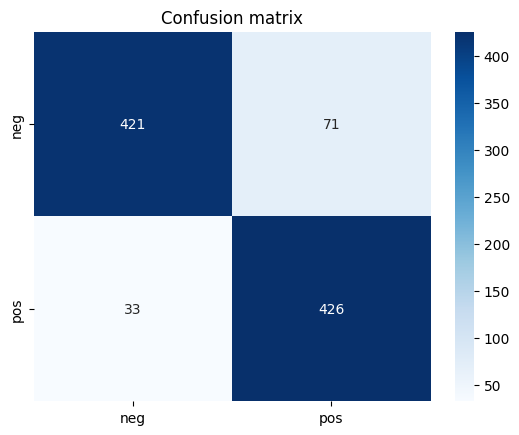

PPL 24.672 | Acc 0.89064 | Prec 0.85714 | Rec 0.9281 | F1 0.89121


Epoch 2/4:   0%|          | 0/625 [00:00<?, ?it/s]

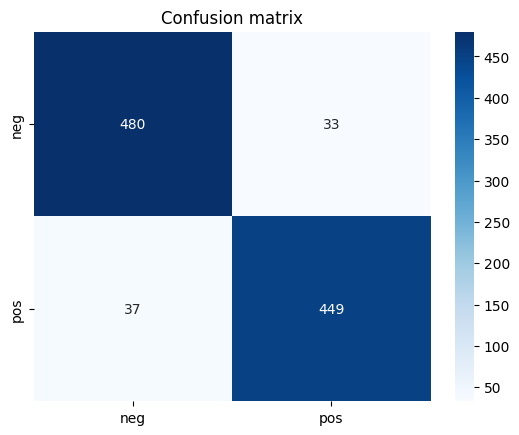

PPL 4.9394 | Acc 0.92993 | Prec 0.93154 | Rec 0.92387 | F1 0.92769


Epoch 3/4:   0%|          | 0/625 [00:00<?, ?it/s]

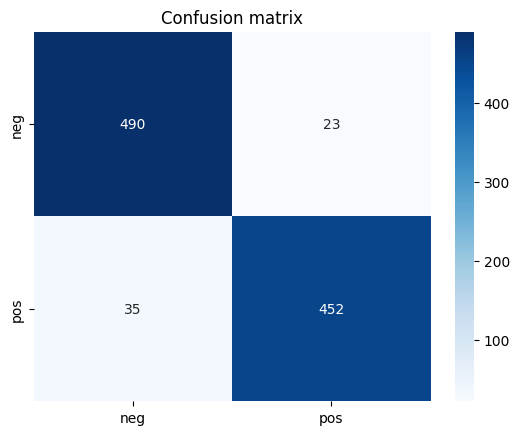

PPL 3.1904 | Acc 0.942 | Prec 0.95158 | Rec 0.92813 | F1 0.93971


Epoch 4/4:   0%|          | 0/625 [00:00<?, ?it/s]

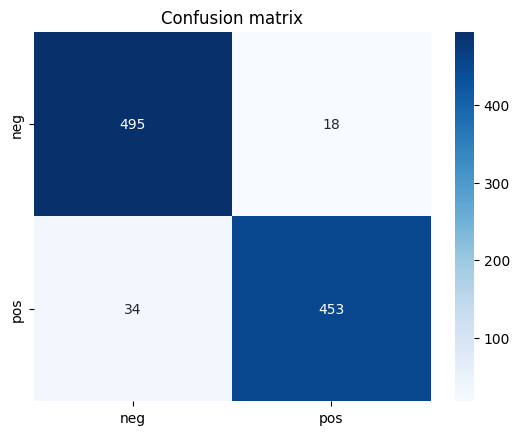

PPL 2.9017 | Acc 0.948 | Prec 0.96178 | Rec 0.93018 | F1 0.94572


In [7]:
# ------ Frozen-Layer Fine-Tuning ------
Config.EPOCHS = 4
base_model = GPT2LMHeadModel.from_pretrained(Config.MODEL_NAME)
base_model.config.pad_token_id = tokeniser.pad_token_id
base_model.to(DEVICE)

# Freeze all but last transformer block + lm_head
for param in base_model.transformer.parameters():
    param.requires_grad = False
for param in base_model.transformer.h[-1].parameters():
    param.requires_grad = True
for param in base_model.lm_head.parameters():
    param.requires_grad = True

print("Trainable parameters (frozen-layer FT):",
      sum(p.numel() for p in base_model.parameters() if p.requires_grad))
train(base_model, "Frozen-Layer Fine-Tuning")

In [8]:
del base_model; gc.collect(); torch.cuda.empty_cache()

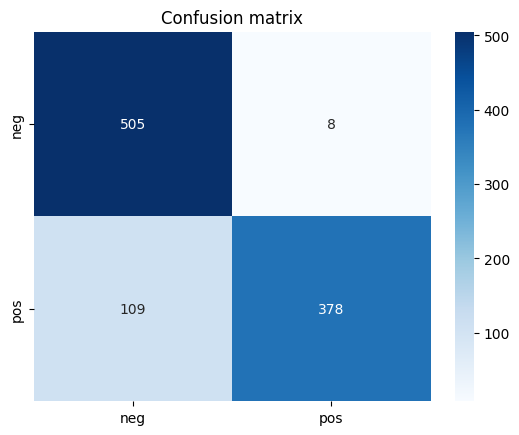

PPL 1.4941 | Acc 0.883 | Prec 0.97927 | Rec 0.77618 | F1 0.86598


Epoch 2/2:   0%|          | 0/625 [00:00<?, ?it/s]

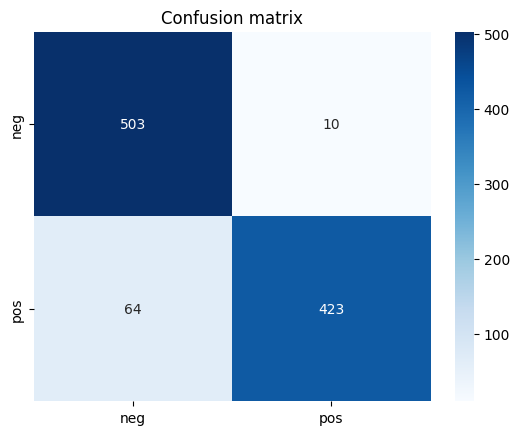

PPL 1.3972 | Acc 0.926 | Prec 0.97691 | Rec 0.86858 | F1 0.91957


In [7]:
# ------ LoRA Fine-Tuning ------
Config.LR = 5e-4 
Config.EPOCHS = 2
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=4,                           
    lora_alpha=8,                 
    lora_dropout=0.05,
    target_modules=["c_attn", "c_proj"],
    bias="none"
)
lora_model = get_peft_model(
    GPT2LMHeadModel.from_pretrained(Config.MODEL_NAME), lora_cfg).to(DEVICE)

lora_model.print_trainable_parameters()
train(lora_model, "LoRA Fine-Tuning")


### **2.4 Evaluation and Result Analysis**

After training the model with the frozen-layer approach, the results show a clear and steady improvement over time. In the first epoch, the accuracy starts around 81%, but by the fourth and final epoch, it reaches an impressive **94.8%**. Perplexity — which measures how confident the model is about its predictions — drops from **25 to just under 3**, meaning the model becomes much more certain about its outputs. The precision and recall scores also improve steadily, and by the end, both are in the 93–96% range, with an overall F1 score of **94.6%**.

The confusion matrices tell the same. In earlier epochs, the model tends to miss more positive reviews, but by the final epoch, the number of misclassified reviews is minimal. This shows that the model gradually learns to handle both sentiment classes well — not just being confident, but also balanced. It’s also worth noting that we achieved this by only training a small part of the model (just the final transformer block and the output head), which saves time and GPU memory compared to fully fine-tuning the entire GPT-2.

Compared to models like BERT that are specifically designed for classification, GPT-2 uses a generative strategy — meaning it *completes* the prompt by predicting the sentiment as a word. This is more flexible but also a bit trickier, since we’re relying on the model to generate the correct word rather than choosing from fixed class logits. While BERT is usually faster and more direct for classification, GPT’s strength is that it can generalize better to other text generation tasks without retraining, making it overall more flexible.

### **2.5 LoRA Fine-Tuning**

To experiment with a more lightweight fine-tuning method, we used LoRA (Low-Rank Adaptation). Instead of updating the main GPT-2 weights, LoRA adds small trainable matrices (in our case, with **rank 4**) into specific attention layers. These adapters are tiny — we only trained **around 0.08%** of the total model parameters — but they still managed to produce strong results. After just two epochs, the model reached **92.6% accuracy** and a perplexity of **1.39**, which is close to what we got using the frozen-layer method.

On the other hand, LoRA gives extremely **high precision** (almost 98%), but its **recall is noticeably lower** at first. That means it's very good at correctly predicting positive reviews when it's confident, but it also tends to miss some — especially more ambiguous reviews. With just a bit more training time or a slightly larger adapter (for example rank 8), that gap would likely decrease. Even so, this level of performance is quite good a tiny fine-tuning.

The big advantage of LoRA is flexibility. We can train multiple task-specific adapters and keep them as small, swappable components without touching the base model. This makes LoRA ideal in situations where compute ation power is limited or where you need to fine-tune for many different tasks.